# NAME: FARHANKHAN PATHAN
# ROLL NO.: 61
# CLASS: CSAI_D-3


 Implement K-Means clustering on Iris.csv dataset. Determine the number of clusters using the elbow method. Dataset Link: https://www.kaggle.com/datasets/uciml/iris

1. Import Libraries

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

Load Dataset

In [13]:
df = pd.read_csv('Iris.csv')

print("First 5 Rows:\n")
print(df.head())

First 5 Rows:

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


Prepare Data

In [14]:
X = df[['PetalLengthCm', 'PetalWidthCm']]

print("\nSelected Features:\n")
print(X.head())


Selected Features:

   PetalLengthCm  PetalWidthCm
0            1.4           0.2
1            1.4           0.2
2            1.3           0.2
3            1.5           0.2
4            1.4           0.2


In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nScaled Data Sample:\n")
print(X_scaled[:5])


Scaled Data Sample:

[[-1.3412724  -1.31297673]
 [-1.3412724  -1.31297673]
 [-1.39813811 -1.31297673]
 [-1.2844067  -1.31297673]
 [-1.3412724  -1.31297673]]


Elbow Method (Find Optimal K)

In [16]:
wcss = []

for i in range(1, 11):
    kmeans_temp = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans_temp.fit(X_scaled)
    wcss.append(kmeans_temp.inertia_)



Plot Elbow Graph

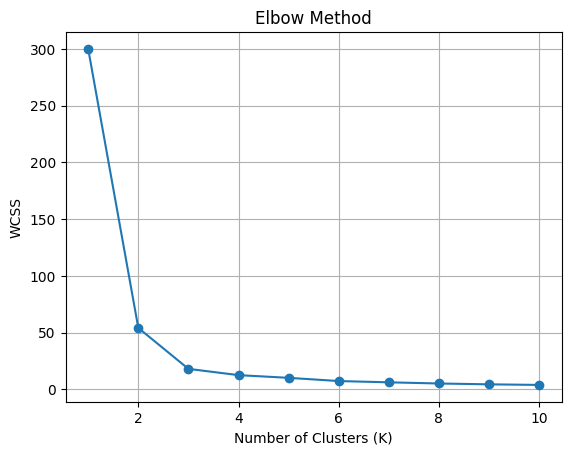

In [17]:
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid()
plt.show()

In [19]:
print("\nFrom the elbow graph, the bend occurs at K = 3.")
print("Hence, the optimal number of clusters is chosen as 3.")


From the elbow graph, the bend occurs at K = 3.
Hence, the optimal number of clusters is chosen as 3.


Apply K-Means (K = 3)

In [20]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

Compare clusters with actual species

In [21]:
comparison = pd.crosstab(y_kmeans, df['Species'])

print("\nCluster vs Actual Species:\n")
print(comparison)


Cluster vs Actual Species:

Species  Iris-setosa  Iris-versicolor  Iris-virginica
row_0                                                
0                  0                2              46
1                 50                0               0
2                  0               48               4


Visualize Clusters

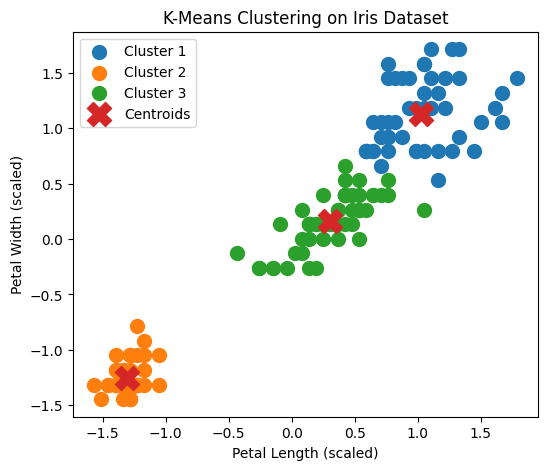

In [22]:
plt.figure(figsize=(6,5))

plt.scatter(X_scaled[y_kmeans == 0, 0], X_scaled[y_kmeans == 0, 1],
            s=100, label='Cluster 1')

plt.scatter(X_scaled[y_kmeans == 1, 0], X_scaled[y_kmeans == 1, 1],
            s=100, label='Cluster 2')

plt.scatter(X_scaled[y_kmeans == 2, 0], X_scaled[y_kmeans == 2, 1],
            s=100, label='Cluster 3')

plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=300, marker='X', label='Centroids')

plt.xlabel('Petal Length (scaled)')
plt.ylabel('Petal Width (scaled)')
plt.title('K-Means Clustering on Iris Dataset')
plt.legend()

plt.show()